# Modelagem do sistema mecânico 1GDL

## Bibliotecas

In [19]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

## Dados do problema

In [20]:
# Roda dianteira esquerda (rigidez 1 turma 1)
m1 = 48.1 #kg
wn1 = 44.83 #rad/s
xi1 = 0.088 #Fator de amortecimento 

# Roda traseira esquerda (rigidez 1 turma 1)
m2 = 63.8 #Kg
wn2 = 47.75 #rad/s
xi2 = 0.117 #Fator de amortecimento

## Cálculo do K (teórico)

In [21]:
# wn = (K/m)**1/2
# K = wn**2 * m

# Roda dianteira esquerda (rigidez 1 turma 1)
k1 = wn1**2 * m1

# Roda traseira esquerda (rigidez 1 turma 1)
k2 = wn2**2 * m2 

print(k1, k2)

96667.96009 145467.9875


## Cálculo do C 

In [22]:
# xi = c/2m*wn
# c = xi*2m*wn

# Roda dianteira esquerda (rigidez 1 turma 1)
c1 = xi1*2*m1*wn1

# Roda traseira esquerda (rigidez 1 turma 1)
c2 = xi2*2*m2*wn2

print(c1, c2)

379.512848 712.8693


## Equação do movimento

In [23]:
# mx''+cx'+kx = F(t)
# x''(t) + 2xi*wnx'(t) + wn**2x(t) #Eq. do movimento dividida pela massa

# Roda dianteira esquerda
print (f"{m1}x'' + {c1}x' + {k1}x = F(t)")
print (f"x''(t) + {2*xi1*wn1}x'(t) + {wn1**2}x(t) = 0")
# Roda traseira esquerda
print (f"{m2}x'' + {c2}x' + {k2}x = F(t)")
print (f"x''(t) + {2*xi2*wn2}x'(t) + {wn2**2}x(t) = 0")

48.1x'' + 379.512848x' + 96667.96009x = F(t)
x''(t) + 7.890079999999999x'(t) + 2009.7288999999998x(t) = 0
63.8x'' + 712.8693x' + 145467.9875x = F(t)
x''(t) + 11.1735x'(t) + 2280.0625x(t) = 0


## Resolução da EDO (subamortecido) 0 < xi < 1

In [24]:
# x(t) = c * exp**(-xi*wn*t) * sin(wd*t - theta) 
# wd = wn * (1 - xi**2)**1/2 # Frequência natural amortecida
# c = x0**2 + [(xi*wn*x0 + v0) / wd]**1/2
# theta = tg**-1 [(xi*wn + v0) / wd*x0]

# Condições iniciais
x0 = 0
a0 = -0.8 # Aceleração inicial lida do gráfico experimental (m/s²)
v0 = (-a0 - (wn1**2) * x0) / (2 * xi1 * wn1)

t = np.linspace (0, 2, 5000)

# Roda dianteira esquerda (rigidez 1 turma 1)
wd1 = wn1 * np.sqrt(1 - xi1**2)
ct1 = np.sqrt(x0**2 + ((xi1*wn1*x0 + v0) / wd1)**2)
theta1 = np.atan((xi1*wn1 + v0) / wd1*x0)
xt1 = ct1 * np.e**(-xi1*wn1*t) * np.sin(wd1*t - theta1)

#Velocidade x'(t)
vt1 = ct1 * np.exp(-xi1*wn1*t) * (wd1 * np.cos(wd1*t - theta1) - xi1*wn1 * np.sin(wd1*t - theta1))
# Aceleração x''(t)
at1 = -2 * xi1 * wn1 * vt1 - (wn1**2) * xt1

# Roda traseira esquerda (rigidez 1 turma 1)
wd2 = wn2 * np.sqrt(1 - xi2**2)
ct2 = np.sqrt(x0**2 + ((xi2*wn2*x0 + v0) / wd2)**2)
theta2 = np.atan((xi2*wn2 + v0) / wd2*x0)
xt2 = ct2 * np.e**(-xi2*wn2*t) * np.sin(wd2*t - theta2)

#Velocidade
vt2 = ct2 * np.exp(-xi2*wn2*t) * (wd2 * np.cos(wd2*t - theta2) - xi2*wn2 * np.sin(wd2*t - theta2))
# Aceleração
at2 = -2 * xi2 * wn2 * vt2 - (wn2**2) * xt2

print (v0)

0.10139314176789084


## Resposta livre no tempo 

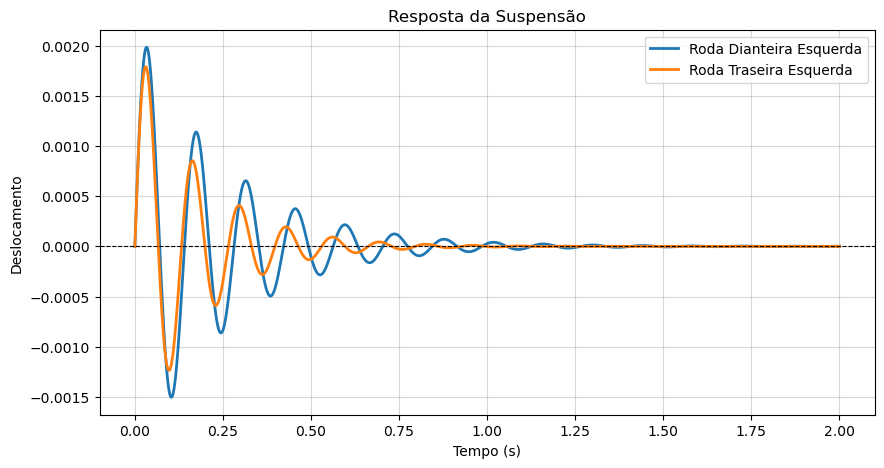

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(t, xt1, label='Roda Dianteira Esquerda', linewidth=2)
plt.plot(t, xt2, label='Roda Traseira Esquerda', linewidth=2)
plt.title('Resposta da Suspensão')
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

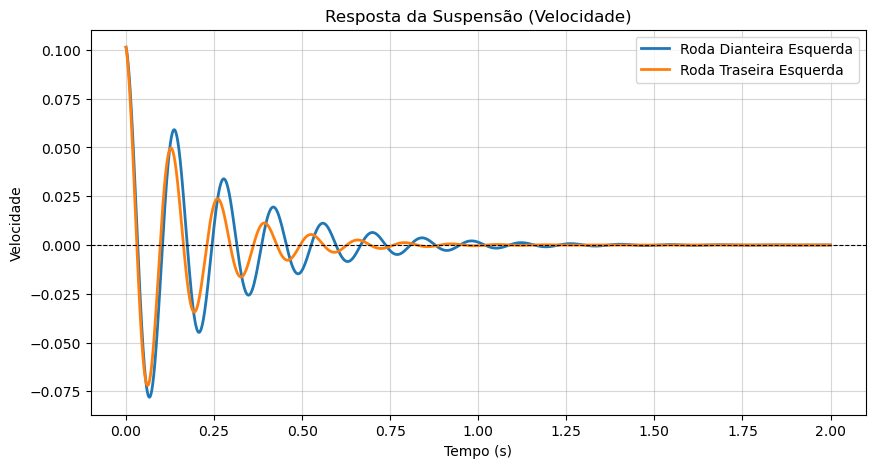

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(t, vt1, label='Roda Dianteira Esquerda', linewidth=2)
plt.plot(t, vt2, label='Roda Traseira Esquerda', linewidth=2)
plt.title('Resposta da Suspensão (Velocidade)')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

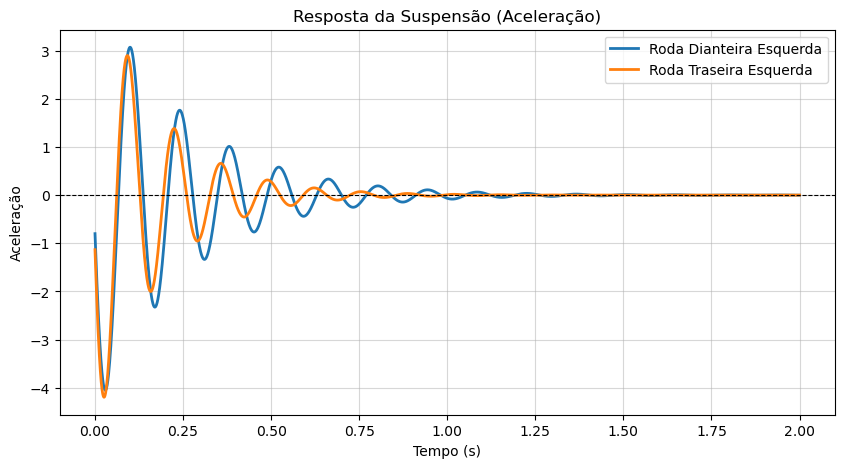

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(t, at1, label='Roda Dianteira Esquerda', linewidth=2)
plt.plot(t, at2, label='Roda Traseira Esquerda', linewidth=2)
plt.title('Resposta da Suspensão (Aceleração)')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

## Gráfico de velocidade x deslocamento

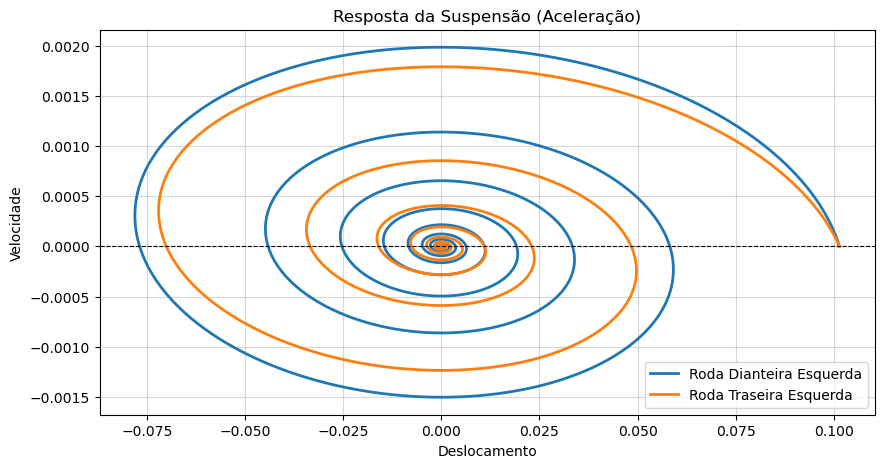

In [28]:
plt.figure(figsize=(10, 5))
plt.plot(vt1, xt1, label='Roda Dianteira Esquerda', linewidth=2)
plt.plot(vt2, xt2, label='Roda Traseira Esquerda', linewidth=2)
plt.title('Resposta da Suspensão (Aceleração)')
plt.xlabel('Deslocamento')
plt.ylabel('Velocidade')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

Validação Numérica do Modelo (Roda Dianteira Esquerda)
Amplitude do Pico 1: 0.00198 m (em t = 0.033 s)
Amplitude do Pico 2: 0.00114 m (em t = 0.174 s)
Decremento Logarítmico (δ): 0.55509
Fator de Amortecimento (ζ) Calculado: 0.08800
Fator de Amortecimento (ζ) de Input:  0.08800
--------------------------------------------------------------


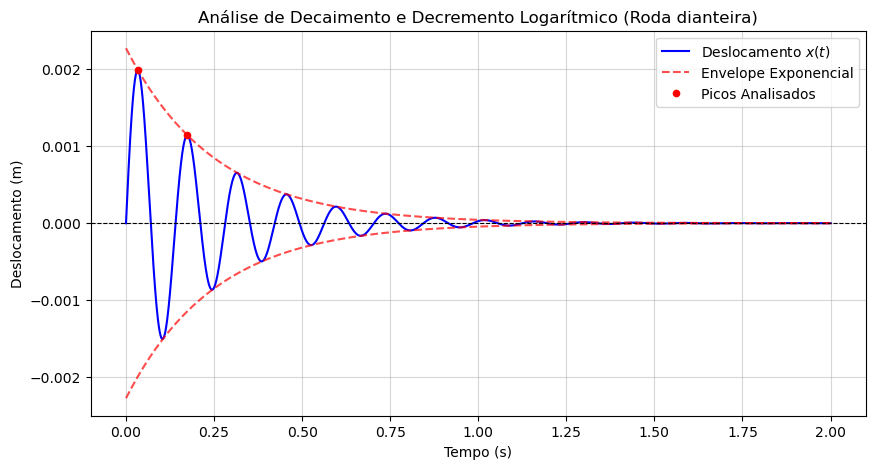

In [30]:
# find_peaks varre o vetor xt1 e encontra os índices dos máximos locais
indices_picos, _ = find_peaks(xt1)

# Extraindo o tempo e a amplitude dos dois primeiros picos
idx_1 = indices_picos[0]
idx_2 = indices_picos[1]

t_pico1, x_pico1 = t[idx_1], xt1[idx_1]
t_pico2, x_pico2 = t[idx_2], xt1[idx_2]

# 2. Cálculo do Decremento e Validação
# Fórmula do Decremento Logarítmico
delta_experimental = np.log(x_pico1 / x_pico2)

# Fórmula invertida para achar o zeta a partir do delta
zeta_experimental = delta_experimental / np.sqrt((2 * np.pi)**2 + delta_experimental**2)

print("Validação Numérica do Modelo (Roda Dianteira Esquerda)")
print(f"Amplitude do Pico 1: {x_pico1:.5f} m (em t = {t_pico1:.3f} s)")
print(f"Amplitude do Pico 2: {x_pico2:.5f} m (em t = {t_pico2:.3f} s)")
print(f"Decremento Logarítmico (δ): {delta_experimental:.5f}")
print(f"Fator de Amortecimento (ζ) Calculado: {zeta_experimental:.5f}")
print(f"Fator de Amortecimento (ζ) de Input:  {xi1:.5f}")
print("-" * 62)

# --- 3. Cálculo do Envelope Exponencial ---
# O envelope é a função que "esmaga" a amplitude da oscilação
envelope_superior = ct1 * np.exp(-xi1 * wn1 * t)
envelope_inferior = -ct1 * np.exp(-xi1 * wn1 * t)

plt.figure(figsize=(10, 5))
# Plota a resposta normal do sistema
plt.plot(t, xt1, label='Deslocamento $x(t)$', color='blue', linewidth=1.5)

# Plota o envelope de decaimento
plt.plot(t, envelope_superior, 'r--', alpha=0.7, label='Envelope Exponencial')
plt.plot(t, envelope_inferior, 'r--', alpha=0.7)

# Marca os dois primeiros picos com um "X" vermelho grande
plt.plot([t_pico1, t_pico2], [x_pico1, x_pico2], "r.", markersize=7, markeredgewidth=2, label='Picos Analisados')

plt.title('Análise de Decaimento e Decremento Logarítmico (Roda dianteira)')
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento (m)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()